In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.datasets import make_circles

X, y = make_circles(n_samples=1000, factor=0.2, noise=0.2, random_state=23)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=23)
clf = LogisticRegression(random_state=23).fit(X_train, y_train)
acc = clf.score(X_test, y_test)
clfp = make_pipeline(
    StandardScaler(), PolynomialFeatures(), LogisticRegression(random_state=23)
)
clfp.fit(X_train, y_train)
accp = clfp.score(X_test, y_test)
print(f"Precisión: {acc:.1%}, con características polinómicas {accp:.1%}")

Precisión: 50.4%, con características polinómicas 99.2%


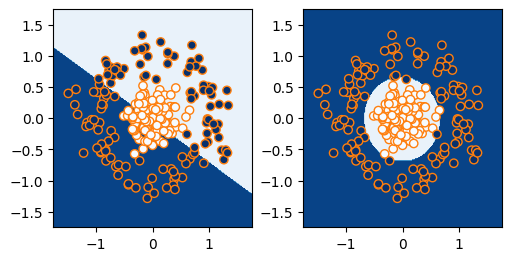

In [9]:
import numpy as np
import matplotlib.pyplot as plt

R = np.linspace(-1.75, 1.75, 200)
X1, X2 = np.meshgrid(R, R)
X = np.c_[np.ravel(X1), np.ravel(X2)]
fig, (ax, axp) = plt.subplots(1, 2, figsize=(5, 2.5), constrained_layout=True)
ax.contourf(X1, X2, clf.predict(X).reshape(X1.shape), 6, cmap="Blues_r")
ax.scatter(*X_test.T, c=y_test, cmap="Blues_r", edgecolors="C1")
axp.contourf(X1, X2, clfp.predict(X).reshape(X1.shape), 6, cmap="Blues_r")
axp.scatter(*X_test.T, c=y_test, cmap="Blues_r", edgecolors="C1")

<br>

# MNIST

In [10]:
import numpy as np
import datasets
from sklearn.decomposition import PCA

# Importamos el dataset, lo normalizamos, y aplicamos PCA
ds = datasets.load_dataset("ylecun/mnist").with_format("numpy")
X_train = ds["train"][:]["image"].astype(np.float32).reshape(-1, 28 * 28) / 255.0
y_train = ds["train"][:]["label"].astype(np.uint8)
K = 300
pca = PCA(n_components=K)
X_train = pca.fit_transform(X_train)

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
import time

start = time.time()
poly = PolynomialFeatures(2)
X_train = poly.fit_transform(X_train)
print(X_train.shape, y_train.shape)
clf = LogisticRegression(C=0.1, max_iter=200).fit(X_train, y_train)
print("Tiempo (hh:mm:ss):", time.strftime("%H:%M:%S", time.gmtime(time.time() - start)))
del X_train, y_train

(60000, 45451) (60000,)


In [ ]:
X_test = ds["test"][:]["image"].astype(np.float32).reshape(-1, 28 * 28) / 255.0
y_test = ds["test"][:]["label"].astype(np.uint8)
X_test = pca.transform(X_test)
X_test = poly.transform(X_test)
print(X_test.shape, y_test.shape)
acc = clf.score(X_test, y_test)
print(f"Precisión: {acc:.2%}")

(10000, 45451) (10000,)
Precisión: 98.32%


<br>

# Fashion-MNIST

In [1]:
import numpy as np
import datasets
from sklearn.decomposition import PCA

# Importamos el dataset, lo normalizamos, y aplicamos PCA
ds = datasets.load_dataset("zalando-datasets/fashion_mnist").with_format("numpy")
X_train = ds["train"][:]["image"].astype(np.float32).reshape(-1, 28 * 28) / 255.0
y_train = ds["train"][:]["label"].astype(np.uint8)
K = 300
pca = PCA(n_components=K)
X_train = pca.fit_transform(X_train)

/home/sergio/.local/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
import time

start = time.time()
poly = PolynomialFeatures(2)
X_train = poly.fit_transform(X_train)
print(X_train.shape, y_train.shape)
clf = LogisticRegression(C=0.1, max_iter=200).fit(X_train, y_train)
print("Tiempo (hh:mm:ss):", time.strftime("%H:%M:%S", time.gmtime(time.time() - start)))
del X_train, y_train

(60000, 45451) (60000,)


/home/sergio/.local/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Tiempo (hh:mm:ss): 00:10:44


In [3]:
X_test = ds["test"][:]["image"].astype(np.float32).reshape(-1, 28 * 28) / 255.0
y_test = ds["test"][:]["label"].astype(np.uint8)
X_test = pca.transform(X_test)
X_test = poly.transform(X_test)
print(X_test.shape, y_test.shape)
acc = clf.score(X_test, y_test)
print(f"Precisión: {acc:.2%}")

(10000, 45451) (10000,)
Precisión: 89.41%


<br>

# CIFAR-10

In [4]:
import numpy as np
import datasets
from sklearn.decomposition import PCA

# Importamos el dataset, lo normalizamos, y aplicamos PCA
ds = datasets.load_dataset("uoft-cs/cifar10").with_format("numpy")
X_train = ds["train"][:]["img"].astype(np.float32).reshape(-1, 32 * 32 * 3) / 255.0
y_train = ds["train"][:]["label"].astype(np.uint8)
K = 300
pca = PCA(n_components=K)
X_train = pca.fit_transform(X_train)

In [5]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
import time

start = time.time()
poly = PolynomialFeatures(2)
X_train = poly.fit_transform(X_train)
print(X_train.shape, y_train.shape)
clf = LogisticRegression(C=0.1, max_iter=200).fit(X_train, y_train)
print("Tiempo (hh:mm:ss):", time.strftime("%H:%M:%S", time.gmtime(time.time() - start)))
del X_train, y_train

(50000, 45451) (50000,)


/home/sergio/.local/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Tiempo (hh:mm:ss): 00:08:22


In [6]:
X_test = ds["test"][:]["img"].astype(np.float32).reshape(-1, 32 * 32 * 3) / 255.0
y_test = ds["test"][:]["label"].astype(np.uint8)
X_test = pca.transform(X_test)
X_test = poly.transform(X_test)
print(X_test.shape, y_test.shape)
acc = clf.score(X_test, y_test)
print(f"Precisión: {acc:.2%}")

(10000, 45451) (10000,)
Precisión: 52.80%
